In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("./bank-additional/bank-additional/bank-additional-full.csv",delimiter=";")
df.head(100)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,45,services,married,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
96,42,management,married,university.degree,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
97,53,admin.,divorced,university.degree,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
98,37,technician,single,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df = pd.DataFrame(df)

test = df['month'].unique()
test = np.sort(test)
print(test)

['apr' 'aug' 'dec' 'jul' 'jun' 'mar' 'may' 'nov' 'oct' 'sep']


In [4]:
allowed_y = {'yes', 'no'}

if not set(df['y'].unique()).issubset(allowed_y):
    raise ValueError(
        f"Target column contains values outside {allowed_y}"
    )

# ------------------------------------------------------------------
# 3. Count the occurrences using a cross‑tabulation
# ------------------------------------------------------------------
job_target_counts = pd.crosstab(df['month'], df['y'])

print("Counts of ‘yes’ / ‘no’ per job category:")
job_target_counts = pd.DataFrame(job_target_counts)
job_target_counts

Counts of ‘yes’ / ‘no’ per job category:


y,no,yes
month,,
apr,2093,539
aug,5523,655
dec,93,89
jul,6525,649
jun,4759,559
mar,270,276
may,12883,886
nov,3685,416
oct,403,315


In [5]:
job_target_percentages = (
    job_target_counts.div(job_target_counts.sum(axis=1), axis=0) * 100
).round(2)

print("\nPercentages of ‘yes’ / ‘no’ per job category:")
print(job_target_percentages)


Percentages of ‘yes’ / ‘no’ per job category:
y         no    yes
month              
apr    79.52  20.48
aug    89.40  10.60
dec    51.10  48.90
jul    90.95   9.05
jun    89.49  10.51
mar    49.45  50.55
may    93.57   6.43
nov    89.86  10.14
oct    56.13  43.87
sep    55.09  44.91


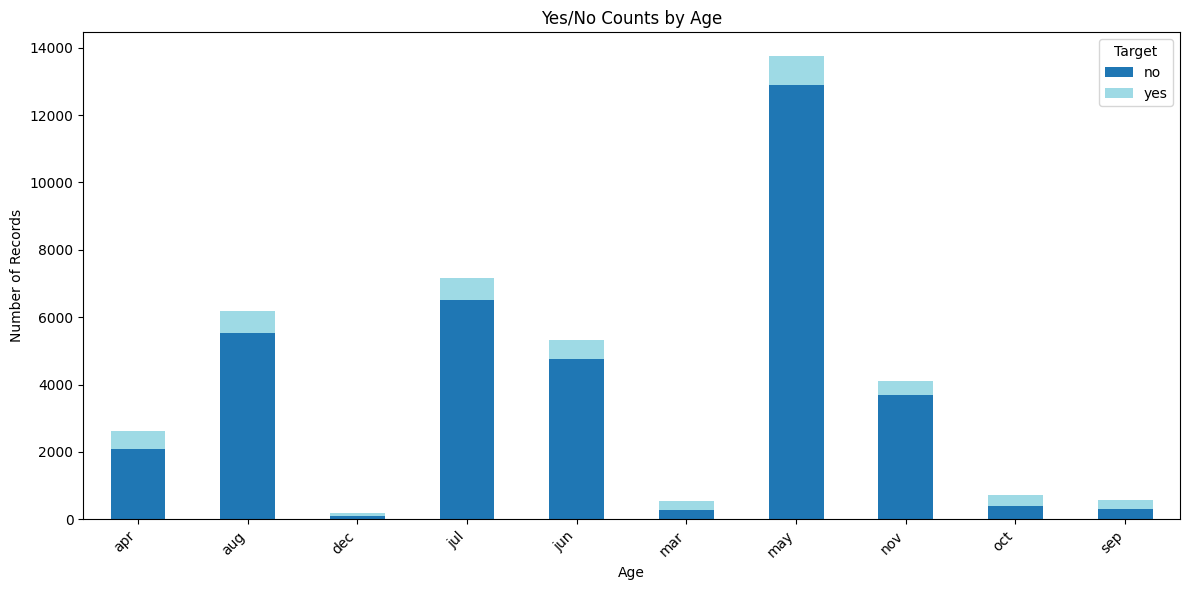

In [6]:
# ------------------------------------------------------------------
# 3a) Stacked bar chart (good if you want to compare totals)
# ------------------------------------------------------------------
ax = job_target_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='tab20',          # a nice palette for the two groups
)

plt.title('Yes/No Counts by Age')
plt.ylabel('Number of Records')
plt.xlabel('Age')
# Show legend title (optional)
ax.legend(title='Target')

# Optional: rotate x‑labels if ages are many or long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

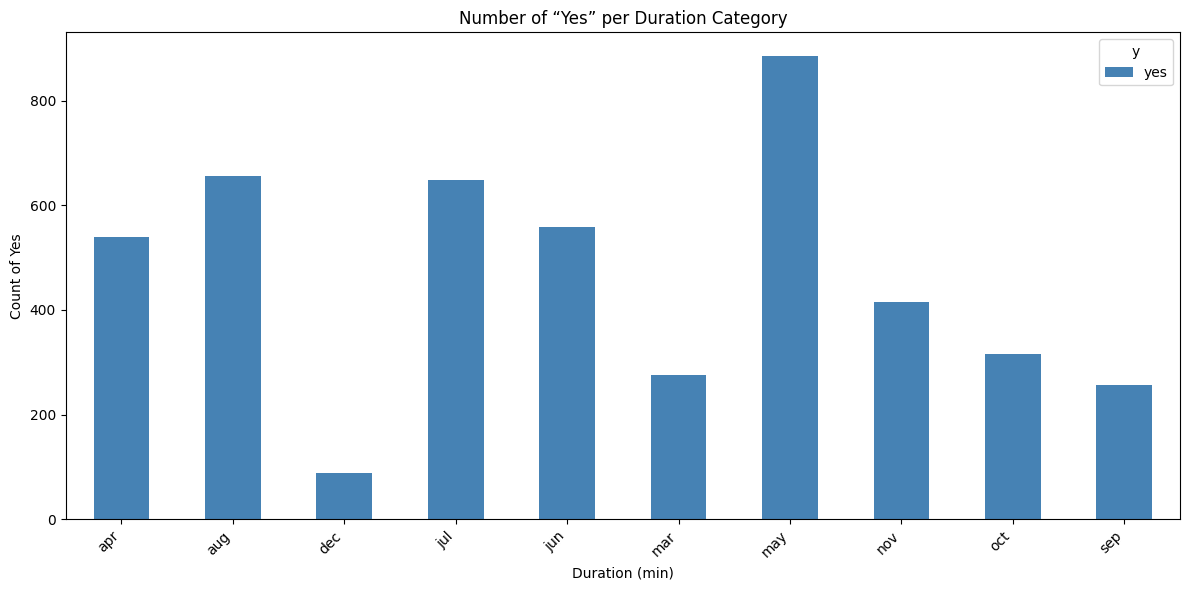

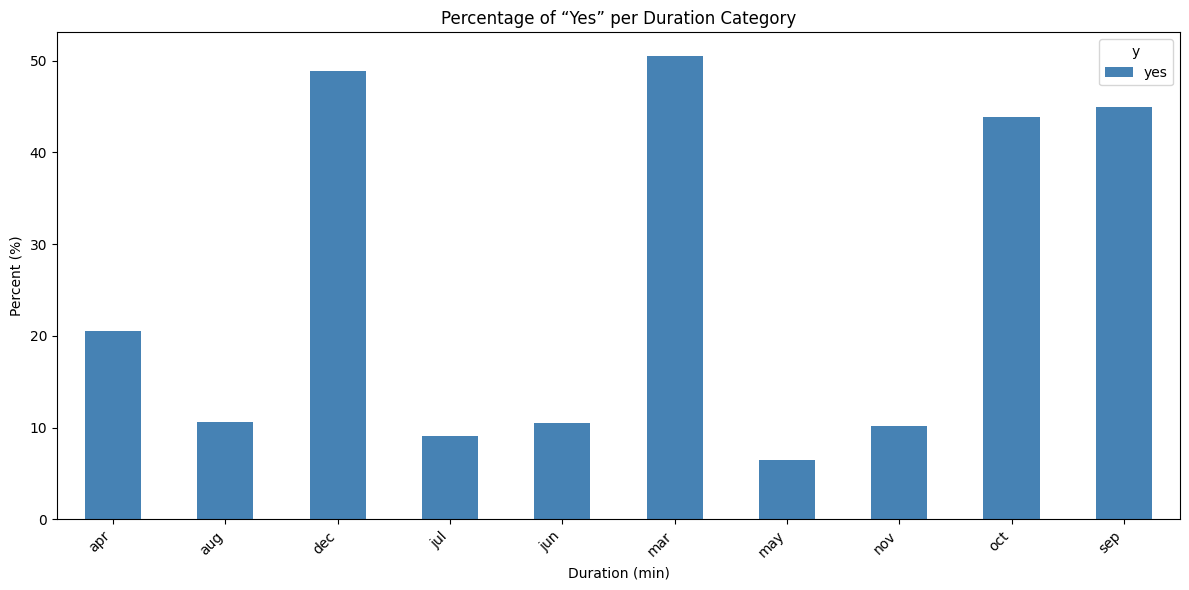

In [8]:
# ------------------------------------------------------------------
# 4️⃣ Keep only the 'yes' part of the tables
# ------------------------------------------------------------------

# --- Counts ---------------------------------------------------------
job_target_yes_counts = job_target_counts[['yes']]   # 1‑column DataFrame



# --- Percentages ----------------------------------------------------
job_target_yes_percentages = job_target_percentages[['yes']]



# ------------------------------------------------------------------
# 5️⃣ Optional: Plot just the 'yes' counts
# ------------------------------------------------------------------

ax = job_target_yes_counts.plot(
    kind='bar',
    figsize=(12, 6),
    color='steelblue',          # you can pick any palette you like
)

plt.title('Number of “Yes” per Duration Category')
plt.ylabel('Count of Yes')
plt.xlabel('Duration (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6️⃣ If you prefer to see the percentages instead of raw counts:
# ------------------------------------------------------------------

ax = job_target_yes_percentages.plot(
    kind='bar',
    figsize=(12, 6),
    color='steelblue',
)

plt.title('Percentage of “Yes” per Duration Category')
plt.ylabel('Percent (%)')
plt.xlabel('Duration (min)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### tingkatkan penawaran pada bulan desember, mungkin karena banyak tunjangan yang turun, menyebabkan conversion rate yang besar, coba tingkatkan pada 

1. december
2. maret
3. october
4. september

mungkin kurangi pada :

1. july
2. may

### harusnya data tidak menggambarkan apa apa, karena bulan saya tidak memiliki konteks yang cukup, tapi hasil tetap menggambarkan pola